# E-Commerce Customer Churn Prediction

**Project Description:** This model predicts whether a customer will churn (stop using the e-commerce platform) based on customer profiles, payment/purchase behaviors, and app engagement metrics.

**Algorithm:** It utilizes **Logistic Regression**, a classification algorithm that applies the sigmoid function to map linear combinations of scaled features to probabilities between 0 and 1, optimized using L2 regularization.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
%matplotlib inline

Step 1: Import the Dataset

In [48]:
df = pd.read_excel("./Dataset/E Commerce Dataset.xlsx", sheet_name="E Comm")

In [49]:
df.shape

(5630, 20)

In [50]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


Step 2: Clean Missing Values

In [51]:
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [52]:
num_cols_with_nas = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

for col in num_cols_with_nas:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [53]:
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

Step 3: Handle Outliers & Categorical Text

In [54]:
print(df['PreferredLoginDevice'].unique())
print(df['PreferredPaymentMode'].unique())

<ArrowStringArray>
['Mobile Phone', 'Phone', 'Computer']
Length: 3, dtype: str
<ArrowStringArray>
['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD',
 'Credit Card']
Length: 7, dtype: str


In [55]:
device_map = {'Mobile Phone': 'Mobile Phone', 'Phone': 'Mobile Phone', 'Computer': 'Computer'}
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].map(device_map)

In [56]:
payment_map = {
    'Debit Card': 'Debit Card', 'UPI': 'UPI', 'E Wallet': 'E Wallet',
    'CC': 'Credit Card', 'Credit Card': 'Credit Card',
    'COD': 'Cash on Delivery', 'Cash on Delivery': 'Cash on Delivery'
}
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].map(payment_map)

In [57]:
if 'PreferedOrderCat' in df.columns:
    df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

In [58]:
categorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
final_df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [59]:
final_df.shape

(5630, 26)

Step 4: Visualize the Class Separation

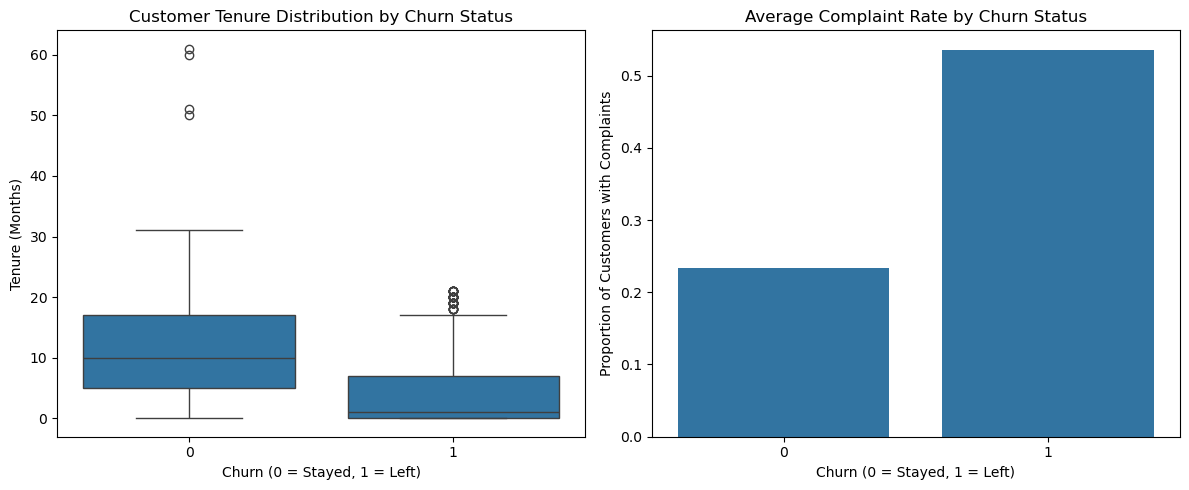

In [60]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Churn', y='Tenure')
plt.title('Customer Tenure Distribution by Churn Status')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Tenure (Months)')

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Churn', y='Complain', errorbar=None)
plt.title('Average Complaint Rate by Churn Status')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Proportion of Customers with Complaints')

plt.tight_layout()
plt.show()

Step 5: Isolate Target and Split the Data

In [61]:
y = final_df['Churn']
X = final_df.drop(columns=['Churn', 'CustomerID'], errors='ignore')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 6: Feature Scaling (Crucial for Logistic Regression!)

In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Step 7: Train the Logistic Regression Model

In [63]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Step 8: Predict Class Probabilities

In [64]:
churn_probabilities = log_model.predict_proba(X_test_scaled)[:, 1]

y_pred = log_model.predict(X_test_scaled)

Step 9: Evaluate via Confusion Matrix and ROC AUC Score

In [70]:
from sklearn.metrics import confusion_matrix, roc_auc_score

cf = confusion_matrix(y_test, y_pred)
auc_score = roc_auc_score(y_test, churn_probabilities)

print("Confusion matrix: \n", cf)
print(f"\nModel AUC Score: {auc_score:.4f}")

Confusion matrix: 
 [[918  23]
 [ 75 110]]

Model AUC Score: 0.8981


Step 10: Plot Receiver Operating Characteristic (ROC) Curve

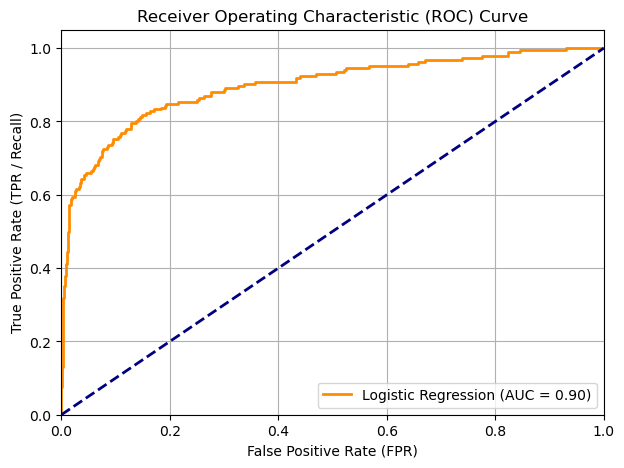

In [66]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, churn_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Step 11: Optimize the Decision Threshold (Reducing the Threshold)

In [67]:
custom_threshold = 0.35
y_pred_custom = (churn_probabilities >= custom_threshold).astype(int)

cm_custom = confusion_matrix(y_test, y_pred_custom)
cm_custom

array([[874,  67],
       [ 55, 130]])

**Analysis of Threshold Reduction:**

By default, logistic regression uses a probability threshold of `0.5` to classify instances. However, for business use cases like customer churn prediction, the cost of a False Negative (failing to identify a customer who is about to churn) is typically much higher than the cost of a False Positive (identifying a customer as churn risk when they actually stay, resulting in minor retention outreach/incentive cost).

By lowering the decision threshold to `0.35`, we make the model more sensitive to churn risk:

* **Default Threshold (0.5):** Captured **110 True Positives** but missed **75 False Negatives**.
* **Custom Threshold (0.35):** Captures **130 True Positives** and reduces False Negatives to **55**.
* **Trade-off:** While False Positives increased from **23 to 67**, the business successfully identifies **20 additional churning customers**, significantly reducing customer churn losses.

Step 12: Compare Sigmoid Curve and Decision Boundaries (0.5 vs 0.35) Side-by-Side

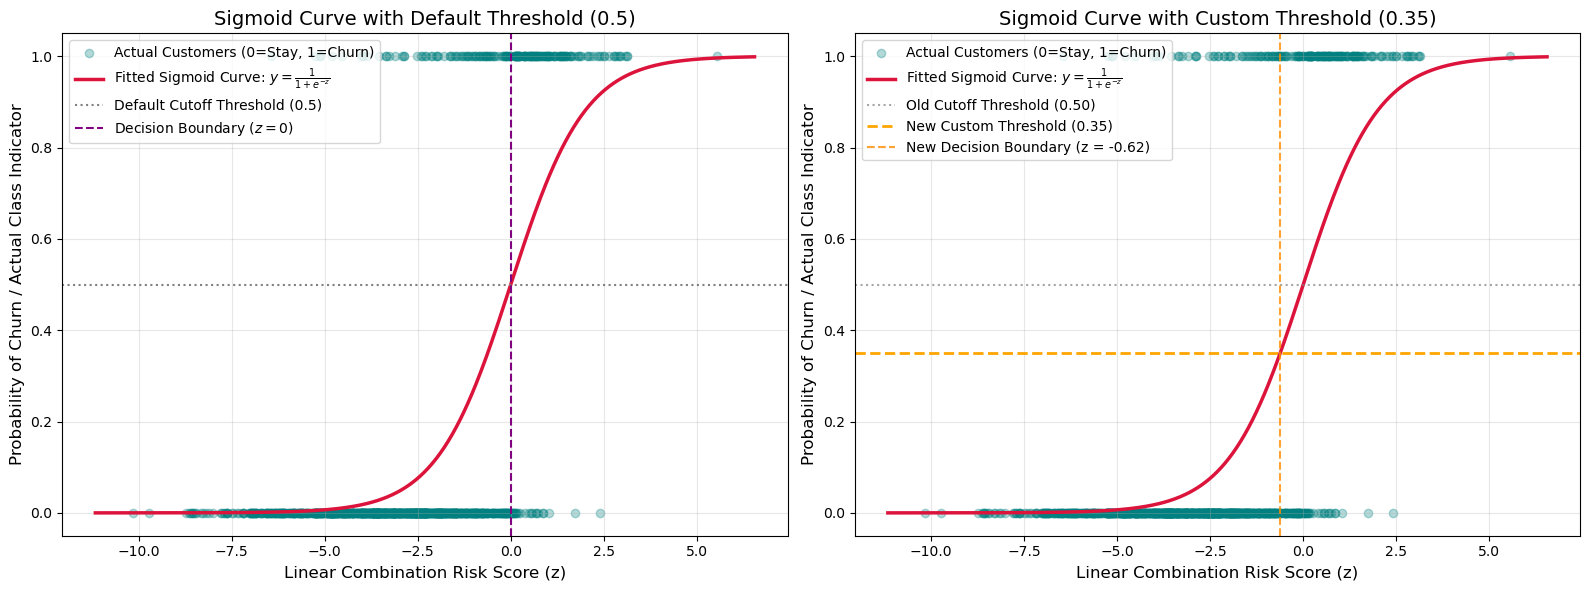

In [68]:
import numpy as np
import matplotlib.pyplot as plt

z_scores = log_model.decision_function(X_test_scaled)
z_curve = np.linspace(z_scores.min() - 1, z_scores.max() + 1, 500)
sigmoid_curve = 1 / (1 + np.exp(-z_curve))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(z_scores, y_test, color='teal', alpha=0.3, label='Actual Customers (0=Stay, 1=Churn)')
ax1.plot(z_curve, sigmoid_curve, color='crimson', linewidth=2.5, label=r'Fitted Sigmoid Curve: $y = \frac{1}{1 + e^{-z}}$')
ax1.axhline(0.5, color='gray', linestyle=':', label='Default Cutoff Threshold (0.5)')
ax1.axvline(0, color='purple', linestyle='--', label='Decision Boundary ($z = 0$)')
ax1.set_title('Sigmoid Curve with Default Threshold (0.5)', fontsize=14)
ax1.set_xlabel('Linear Combination Risk Score (z)', fontsize=12)
ax1.set_ylabel('Probability of Churn / Actual Class Indicator', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.scatter(z_scores, y_test, color='teal', alpha=0.3, label='Actual Customers (0=Stay, 1=Churn)')
ax2.plot(z_curve, sigmoid_curve, color='crimson', linewidth=2.5, label=r'Fitted Sigmoid Curve: $y = \frac{1}{1 + e^{-z}}$')
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='Old Cutoff Threshold (0.50)')
ax2.axhline(0.35, color='orange', linestyle='--', linewidth=2, label='New Custom Threshold (0.35)')
z_boundary_custom = -np.log((1 / 0.35) - 1)
ax2.axvline(z_boundary_custom, color='darkorange', linestyle='--', alpha=0.8, label=f'New Decision Boundary (z = {z_boundary_custom:.2f})')
ax2.set_title('Sigmoid Curve with Custom Threshold (0.35)', fontsize=14)
ax2.set_xlabel('Linear Combination Risk Score (z)', fontsize=12)
ax2.set_ylabel('Probability of Churn / Actual Class Indicator', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()